In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import re
import nltk
from nltk.corpus import stopwords
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import BernoulliNB, ComplementNB
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv('train.csv',names=['polarity', 'title', 'text'])
test_df = pd.read_csv('test.csv',names=['polarity', 'title', 'text'])

In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text) 
    text = re.sub(r"\d+", "", text)  
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Quantum\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
train_df['clean_text'] = (train_df['title'] + " " + train_df['text']).apply(clean_text)
test_df['clean_text'] = (test_df['title'] + " " + test_df['text']).apply(clean_text)

In [ ]:
vectorizer = TfidfVectorizer(max_features=10000, min_df=5, max_df=0.9)
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])
y_train = train_df['polarity'] - 1 
y_test = test_df['polarity'] - 1

In [ ]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=['Negative', 'Positive']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.8433

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84    200000
    Positive       0.84      0.84      0.84    200000

    accuracy                           0.84    400000
   macro avg       0.84      0.84      0.84    400000
weighted avg       0.84      0.84      0.84    400000


Confusion Matrix:
[[168884  31116]
 [ 31555 168445]]


In [26]:
acc  = accuracy_score(y_test, predictions)
prec = precision_score(y_test, predictions, average='weighted')
rec  = recall_score(y_test, predictions, average='weighted')
f1   = f1_score(y_test, predictions, average='weighted')

print(f"Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}  ({prec*100:.2f}%)")
print(f"Recall    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")


Accuracy  : 0.8433  (84.33%)
Precision : 0.8433  (84.33%)
Recall    : 0.8433  (84.33%)
F1-Score  : 0.8433  (84.33%)


In [11]:
for alpha in [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]:
    nb = MultinomialNB(alpha=alpha)
    nb.fit(X_train, y_train)
    acc = accuracy_score(y_test, nb.predict(X_test))
    print(f"alpha={alpha:<5} → Accuracy: {acc:.4f}")

alpha=0.01  → Accuracy: 0.8433
alpha=0.1   → Accuracy: 0.8433
alpha=0.5   → Accuracy: 0.8433
alpha=1.0   → Accuracy: 0.8433
alpha=2.0   → Accuracy: 0.8434
alpha=5.0   → Accuracy: 0.8434


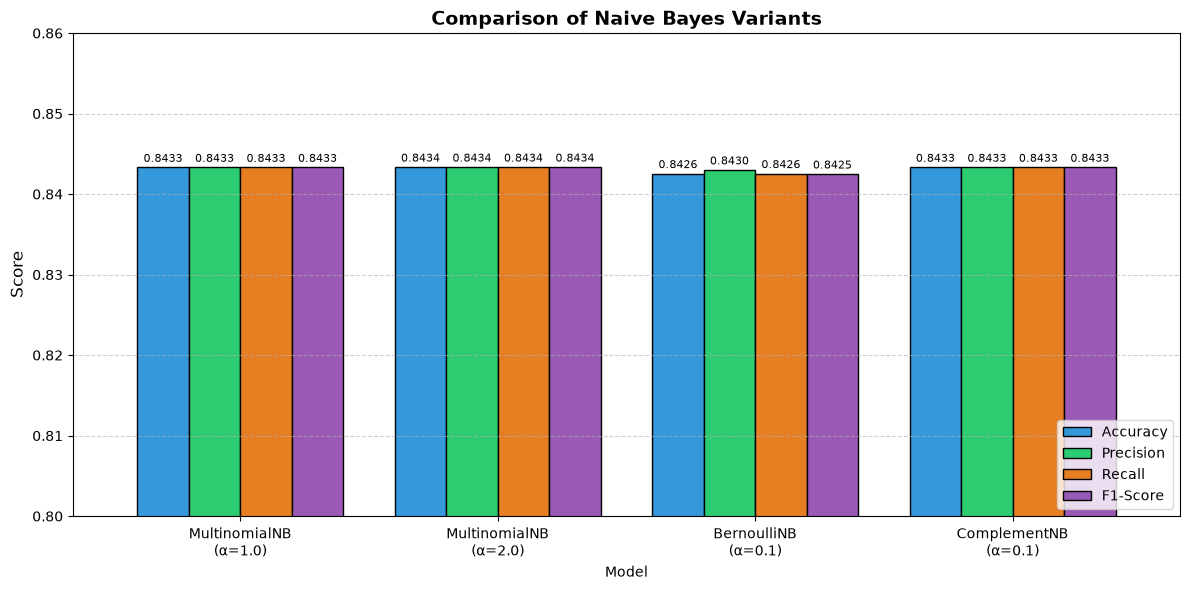

In [ ]:
models = {
    'MultinomialNB\n(α=1.0)': MultinomialNB(alpha=1.0),
    'MultinomialNB\n(α=2.0)': MultinomialNB(alpha=2.0),
    'BernoulliNB\n(α=0.1)'  : BernoulliNB(alpha=0.1),
    'ComplementNB\n(α=0.1)' : ComplementNB(alpha=0.1),
}
results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall'   : recall_score(y_test, pred, average='weighted'),
        'F1-Score' : f1_score(y_test, pred, average='weighted'),
    })
df = pd.DataFrame(results).set_index('Model')
fig, ax = plt.subplots(figsize=(12, 6))
df.plot(kind='bar', ax=ax, width=0.8, edgecolor='black',
        color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2)
ax.set_ylim(0.80, 0.86)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparison of Naive Bayes Variants', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150)
plt.show()

In [ ]:
zbnb = BernoulliNB(alpha=0.1)
bnb.fit(X_train, y_train)
print(f"BernoulliNB Accuracy: {accuracy_score(y_test, bnb.predict(X_test)):.4f}")
cnb = ComplementNB(alpha=0.1)
cnb.fit(X_train, y_train)
print(f"ComplementNB Accuracy: {accuracy_score(y_test, cnb.predict(X_test)):.4f}")

BernoulliNB Accuracy: 0.8426
ComplementNB Accuracy: 0.8433


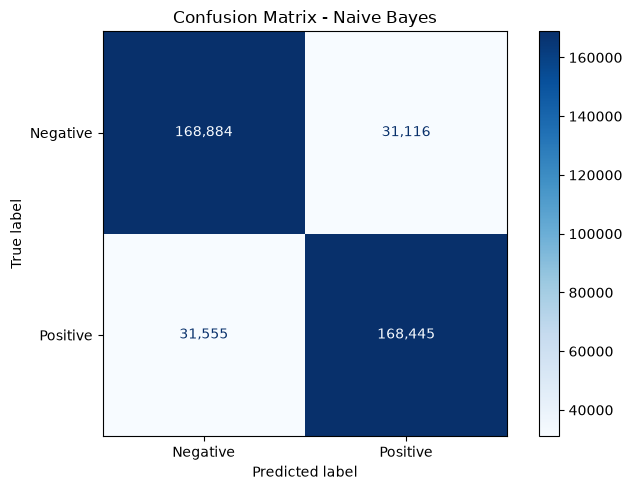

In [ ]:
cm = confusion_matrix(y_test, predictions)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)
disp.plot(cmap='Blues', ax=ax, values_format=',d')
plt.title('Confusion Matrix - Naive Bayes')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import numpy as np
feature_names = np.array(vectorizer.get_feature_names_out())
log_probs = model.feature_log_prob_  # shape: (2, n_features)
for i, label in enumerate(['Negative', 'Positive']):
    top_idx = np.argsort(log_probs[i])[-15:][::-1]
    print(f"\nTop words for {label}:")
    print(", ".join(feature_names[top_idx]))


Top words for Negative:
book, one, would, like, dont, movie, good, get, money, time, product, buy, even, read, much

Top words for Positive:
book, great, good, one, love, read, like, best, movie, well, cd, really, time, would, album


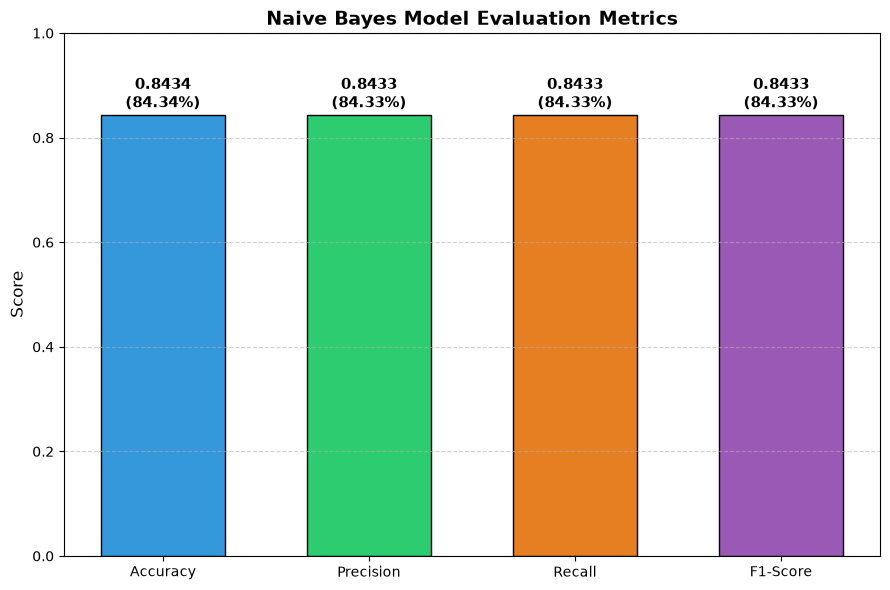

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values  = [acc, prec, rec, f1]

colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(metrics, values, color=colors, edgecolor='black', width=0.6)

for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{v:.4f}\n({v*100:.2f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Naive Bayes Model Evaluation Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150)
plt.show()